# ML Classification Project
### Algorithms: KNN, SVM, Decision Tree
### Datasets: Iris & Breast Cancer

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported!")

All libraries imported!


## Step 2: Load Datasets

In [2]:
# Load Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

print("Iris Dataset")
print("Shape:", df_iris.shape)
print("Classes:", iris.target_names)
print(df_iris['target'].value_counts())
print()
df_iris.head()

Iris Dataset
Shape: (150, 5)
Classes: ['setosa' 'versicolor' 'virginica']
target
0    50
1    50
2    50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Load Breast Cancer dataset
bc = load_breast_cancer()
df_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc['target'] = bc.target

print("Breast Cancer Dataset")
print("Shape:", df_bc.shape)
print("Classes:", bc.target_names)
print(df_bc['target'].value_counts())
print()
df_bc.head()

Breast Cancer Dataset
Shape: (569, 31)
Classes: ['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Step 3: Preprocessing

In [4]:
# Check for missing values
print("Missing values in Iris:", df_iris.isnull().sum().sum())
print("Missing values in Breast Cancer:", df_bc.isnull().sum().sum())

Missing values in Iris: 0
Missing values in Breast Cancer: 0


In [5]:
# Split features and target
X_iris = iris.data
y_iris = iris.target

X_bc = bc.data
y_bc = bc.target

# Train-test split (80% train, 20% test)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

print("Iris Train:", X_iris_train.shape, "| Test:", X_iris_test.shape)
print("BC Train:", X_bc_train.shape, "| Test:", X_bc_test.shape)

Iris Train: (120, 4) | Test: (30, 4)
BC Train: (455, 30) | Test: (114, 30)


In [6]:
# Feature Scaling (needed for KNN and SVM)
scaler = StandardScaler()

X_iris_train_sc = scaler.fit_transform(X_iris_train)
X_iris_test_sc  = scaler.transform(X_iris_test)

scaler2 = StandardScaler()
X_bc_train_sc = scaler2.fit_transform(X_bc_train)
X_bc_test_sc  = scaler2.transform(X_bc_test)

print("Scaling done!")

Scaling done!


## Step 4: KNN - Find Best K Value

In [7]:
# Test different K values
k_values = [1, 5, 7, 20, 51]

iris_accuracies = []
bc_accuracies   = []

for k in k_values:
    # Iris
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_iris_train_sc, y_iris_train)
    acc = accuracy_score(y_iris_test, knn.predict(X_iris_test_sc))
    iris_accuracies.append(acc)

    # Breast Cancer
    knn2 = KNeighborsClassifier(n_neighbors=k)
    knn2.fit(X_bc_train_sc, y_bc_train)
    acc2 = accuracy_score(y_bc_test, knn2.predict(X_bc_test_sc))
    bc_accuracies.append(acc2)

print("K values tested:", k_values)
print("Iris accuracies:", [round(a*100, 2) for a in iris_accuracies])
print("BC accuracies:  ", [round(a*100, 2) for a in bc_accuracies])

K values tested: [1, 5, 7, 20, 51]
Iris accuracies: [100.0, 100.0, 100.0, 100.0, 93.33]
BC accuracies:   [93.86, 94.74, 94.74, 95.61, 95.61]


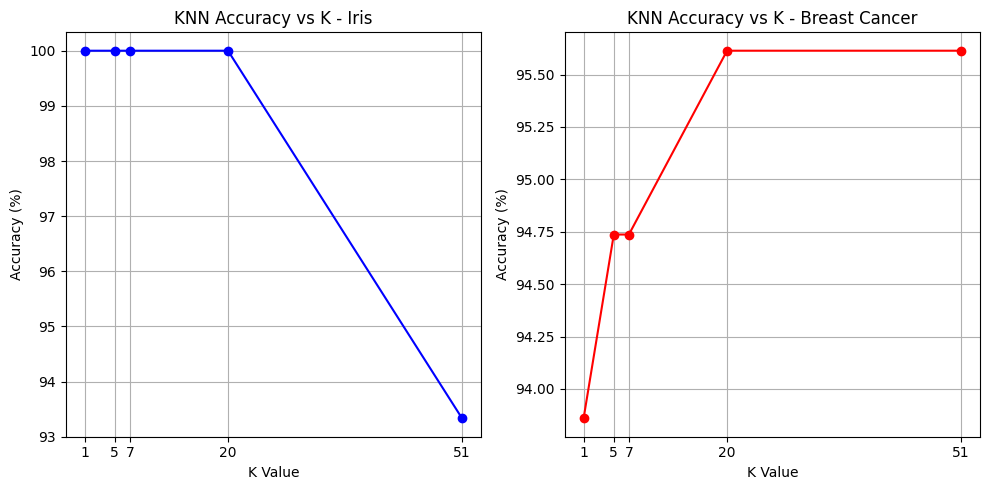

In [8]:
# Plot Accuracy vs K
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, [a*100 for a in iris_accuracies], marker='o', color='blue')
plt.title('KNN Accuracy vs K - Iris')
plt.xlabel('K Value')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, [a*100 for a in bc_accuracies], marker='o', color='red')
plt.title('KNN Accuracy vs K - Breast Cancer')
plt.xlabel('K Value')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.savefig('knn_accuracy_vs_k.png', dpi=150)
plt.show()

In [9]:
# Find optimal K
best_k_iris = k_values[iris_accuracies.index(max(iris_accuracies))]
best_k_bc   = k_values[bc_accuracies.index(max(bc_accuracies))]

print("Best K for Iris:", best_k_iris, "with accuracy", round(max(iris_accuracies)*100, 2), "%")
print("Best K for BC:  ", best_k_bc,   "with accuracy", round(max(bc_accuracies)*100,   2), "%")

Best K for Iris: 1 with accuracy 100.0 %
Best K for BC:   20 with accuracy 95.61 %


## Step 5: Train All 3 Models

In [11]:
# ── KNN ──────────────────────────────────────────────────────────────────────
knn_iris = KNeighborsClassifier(n_neighbors=best_k_iris)
knn_iris.fit(X_iris_train_sc, y_iris_train)

knn_bc = KNeighborsClassifier(n_neighbors=best_k_bc)
knn_bc.fit(X_bc_train_sc, y_bc_train)

# ── SVM ──────────────────────────────────────────────────────────────────────
svm_iris = SVC(kernel='rbf', random_state=42)
svm_iris.fit(X_iris_train_sc, y_iris_train)

svm_bc = SVC(kernel='rbf', random_state=42)
svm_bc.fit(X_bc_train_sc, y_bc_train)

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_iris = DecisionTreeClassifier(random_state=42)
dt_iris.fit(X_iris_train, y_iris_train)   # no scaling needed

dt_bc = DecisionTreeClassifier(random_state=42)
dt_bc.fit(X_bc_train, y_bc_train)

print("All models trained!")

All models trained!


## Step 6: Evaluate Models

In [12]:
# KNN - Iris
y_pred = knn_iris.predict(X_iris_test_sc)
print("=== KNN on Iris ===")
print("Accuracy:", round(accuracy_score(y_iris_test, y_pred)*100, 2), "%")
print(classification_report(y_iris_test, y_pred, target_names=iris.target_names))

=== KNN on Iris ===
Accuracy: 100.0 %
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
# KNN - Breast Cancer
y_pred = knn_bc.predict(X_bc_test_sc)
print("=== KNN on Breast Cancer ===")
print("Accuracy:", round(accuracy_score(y_bc_test, y_pred)*100, 2), "%")
print(classification_report(y_bc_test, y_pred, target_names=bc.target_names))

=== KNN on Breast Cancer ===
Accuracy: 95.61 %
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [14]:
# SVM - Iris
y_pred = svm_iris.predict(X_iris_test_sc)
print("=== SVM on Iris ===")
print("Accuracy:", round(accuracy_score(y_iris_test, y_pred)*100, 2), "%")
print(classification_report(y_iris_test, y_pred, target_names=iris.target_names))

=== SVM on Iris ===
Accuracy: 100.0 %
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
# SVM - Breast Cancer
y_pred = svm_bc.predict(X_bc_test_sc)
print("=== SVM on Breast Cancer ===")
print("Accuracy:", round(accuracy_score(y_bc_test, y_pred)*100, 2), "%")
print(classification_report(y_bc_test, y_pred, target_names=bc.target_names))

=== SVM on Breast Cancer ===
Accuracy: 98.25 %
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [16]:
# Decision Tree - Iris
y_pred = dt_iris.predict(X_iris_test)
print("=== Decision Tree on Iris ===")
print("Accuracy:", round(accuracy_score(y_iris_test, y_pred)*100, 2), "%")
print(classification_report(y_iris_test, y_pred, target_names=iris.target_names))

=== Decision Tree on Iris ===
Accuracy: 100.0 %
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [17]:
# Decision Tree - Breast Cancer
y_pred = dt_bc.predict(X_bc_test)
print("=== Decision Tree on Breast Cancer ===")
print("Accuracy:", round(accuracy_score(y_bc_test, y_pred)*100, 2), "%")
print(classification_report(y_bc_test, y_pred, target_names=bc.target_names))

=== Decision Tree on Breast Cancer ===
Accuracy: 94.74 %
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## Step 7: Confusion Matrices

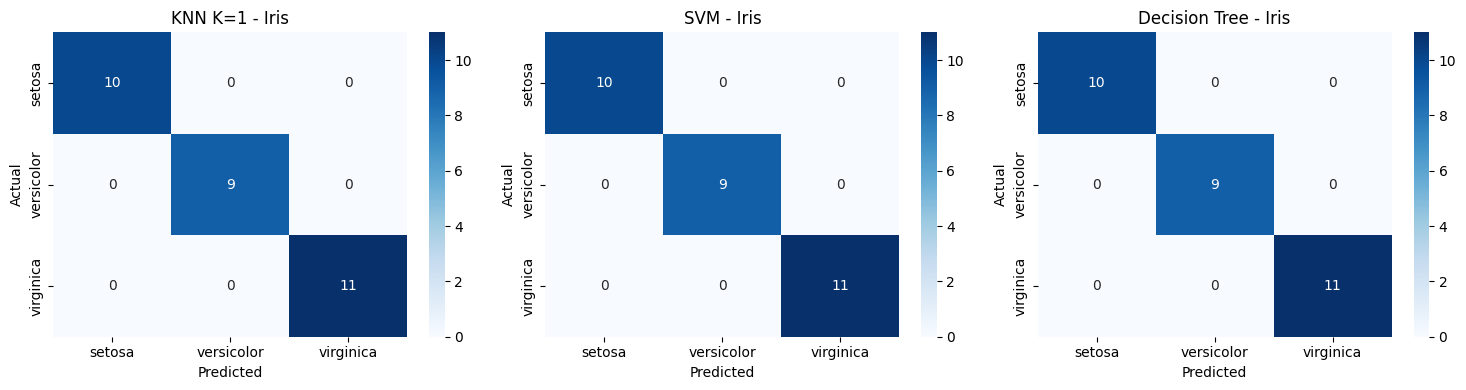

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_iris = [
    (knn_iris.predict(X_iris_test_sc), f"KNN K={best_k_iris}"),
    (svm_iris.predict(X_iris_test_sc),  "SVM"),
    (dt_iris.predict(X_iris_test),      "Decision Tree")
]

for ax, (y_pred, name) in zip(axes, models_iris):
    cm = confusion_matrix(y_iris_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    ax.set_title(f'{name} - Iris')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_iris.png', dpi=150)
plt.show()

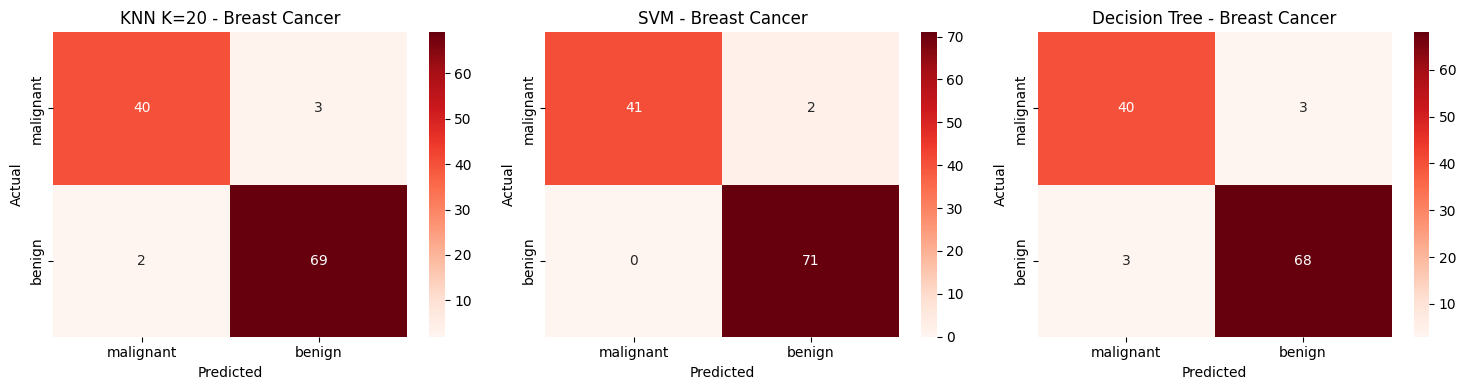

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_bc = [
    (knn_bc.predict(X_bc_test_sc), f"KNN K={best_k_bc}"),
    (svm_bc.predict(X_bc_test_sc),  "SVM"),
    (dt_bc.predict(X_bc_test),      "Decision Tree")
]

for ax, (y_pred, name) in zip(axes, models_bc):
    cm = confusion_matrix(y_bc_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=bc.target_names, yticklabels=bc.target_names)
    ax.set_title(f'{name} - Breast Cancer')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_bc.png', dpi=150)
plt.show()

## Step 8: Compare All Models

In [20]:
# Collect all accuracies
results = {
    'Model': ['KNN', 'SVM', 'Decision Tree'],
    'Iris Accuracy (%)': [
        round(accuracy_score(y_iris_test, knn_iris.predict(X_iris_test_sc))*100, 2),
        round(accuracy_score(y_iris_test, svm_iris.predict(X_iris_test_sc))*100, 2),
        round(accuracy_score(y_iris_test, dt_iris.predict(X_iris_test))*100, 2)
    ],
    'BC Accuracy (%)': [
        round(accuracy_score(y_bc_test, knn_bc.predict(X_bc_test_sc))*100, 2),
        round(accuracy_score(y_bc_test, svm_bc.predict(X_bc_test_sc))*100, 2),
        round(accuracy_score(y_bc_test, dt_bc.predict(X_bc_test))*100, 2)
    ]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

        Model  Iris Accuracy (%)  BC Accuracy (%)
          KNN              100.0            95.61
          SVM              100.0            98.25
Decision Tree              100.0            94.74


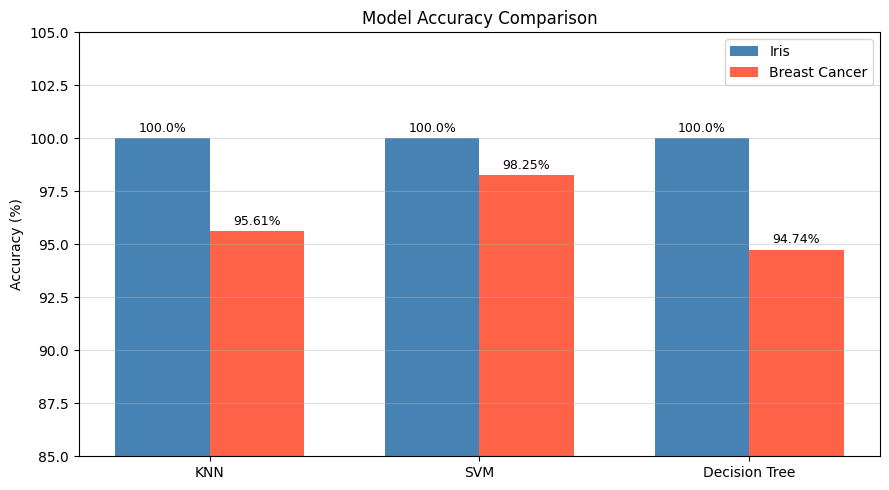

In [21]:
# Bar chart comparison
x = np.arange(3)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, df_results['Iris Accuracy (%)'], width, label='Iris', color='steelblue')
plt.bar(x + width/2, df_results['BC Accuracy (%)'],   width, label='Breast Cancer', color='tomato')

plt.xticks(x, df_results['Model'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim([85, 105])
plt.legend()
plt.grid(axis='y', alpha=0.4)

for i, (iris_acc, bc_acc) in enumerate(zip(df_results['Iris Accuracy (%)'], df_results['BC Accuracy (%)'])):
    plt.text(i - width/2, iris_acc + 0.3, f'{iris_acc}%', ha='center', fontsize=9)
    plt.text(i + width/2, bc_acc   + 0.3, f'{bc_acc}%',  ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()